# MNIST: SVD Optimizer Analysis

Analysis of SVD optimizer (with RMSprop) vs standard optimizers on MNIST classification.
Includes analysis of the `variable_k` setting.

## 1. Setup & Data Loading

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (8, 6),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 2,
    'axes.grid': False,
    'font.family': 'arial',
    'legend.frameon': False
})

PLOT_DIR = Path('plots/mnist')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {PLOT_DIR.resolve()}")

Plots will be saved to: /Users/sambt/iaifi/sv3/analysis/plots/mnist


In [2]:
# Load JSONL results
DATA_PATH = Path('../experiment_results/mnist_scan.jsonl')

records = []
with open(DATA_PATH) as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)
print(f"Total: {len(df)} experiment runs")
print(f"Optimizers: {sorted(df['optimizer'].unique())}")
print(f"Batch sizes: {sorted(df['batch_size'].unique())}")

Total: 90 experiment runs
Optimizers: ['Adam', 'RMSprop', 'SGD', 'SVD']
Batch sizes: [64]


In [3]:
# Helper functions
def get_final_loss(row, loss_type='val'):
    return row['losses'][loss_type][-1]

def get_loss_curve(row, loss_type='val'):
    return np.array(row['losses'][loss_type])

def get_acc_curve(row, acc_type='val_acc'):
    return np.array(row['losses'].get(acc_type, []))

def sliding_average(data, window=10):
    return np.convolve(data, np.ones(window)/window, mode='valid')

# Add derived columns
df['final_val_loss'] = df.apply(lambda r: get_final_loss(r, 'val'), axis=1)
df['final_train_loss'] = df.apply(lambda r: get_final_loss(r, 'train'), axis=1)
df['final_val_acc'] = df.apply(lambda r: r['losses'].get('val_acc', [np.nan])[-1], axis=1)
df['final_train_acc'] = df.apply(lambda r: r['losses'].get('train_acc', [np.nan])[-1], axis=1)
df['total_time'] = df['losses'].apply(lambda l: l.get('total_time', np.nan))
df['avg_epoch_time'] = df['losses'].apply(lambda l: l.get('avg_epoch_time', np.nan))
df['avg_batch_time_train'] = df['losses'].apply(lambda l: l.get('avg_batch_time_train', np.nan))

df_svd = df[df['optimizer'] == 'SVD'].copy()
df_baseline = df[df['optimizer'] != 'SVD'].copy()

# Split SVD by variable_k
df_svd_fixed_k = df_svd[df_svd['variable_k'] == False].copy()
df_svd_var_k = df_svd[df_svd['variable_k'] == True].copy()

bs = sorted(df['batch_size'].unique())[0]  # 64
baseline_optimizers = sorted(df_baseline['optimizer'].unique().tolist())
k_fractions = sorted(df_svd['k_fraction'].dropna().unique())
svd_lrs = sorted(df_svd['lr'].unique())
svd_rtols = sorted(df_svd['rtol'].dropna().unique())

print(f"\nSVD total: {len(df_svd)} runs")
print(f"  fixed_k: {len(df_svd_fixed_k)}, variable_k: {len(df_svd_var_k)}")
print(f"  k_fractions: {k_fractions}")
print(f"  lrs: {svd_lrs}")
print(f"  rtols: {svd_rtols}")
print(f"\nBaseline: {len(df_baseline)} runs")
print(f"  Optimizers: {baseline_optimizers}")
print(f"  lrs: {sorted(df_baseline['lr'].unique())}")


SVD total: 72 runs
  fixed_k: 54, variable_k: 18
  k_fractions: [0.0625, 0.125, 0.25, 0.5, 0.75, 1.0]
  lrs: [0.01, 0.05, 0.1]
  rtols: [1e-10, 0.001, 0.01, 0.1]

Baseline: 18 runs
  Optimizers: ['Adam', 'RMSprop', 'SGD']
  lrs: [0.0001, 0.001, 0.01]


## 2. Best Performance Comparison

Compare the best-performing configuration of each optimizer at matched batch size (64).

In [4]:
# Find best run for each optimizer variant
best_runs = []

# Best SVD fixed-k
best = df_svd_fixed_k.loc[df_svd_fixed_k['final_val_loss'].idxmin()]
best_runs.append({
    'optimizer': 'SVD (fixed k)',
    'final_val_loss': best['final_val_loss'],
    'final_val_acc': best['final_val_acc'],
    'lr': best['lr'],
    'k': best['k'],
    'k_fraction': best['k_fraction'],
    'rtol': best['rtol'],
    'total_time': best['total_time']
})

# Best SVD variable-k
best = df_svd_var_k.loc[df_svd_var_k['final_val_loss'].idxmin()]
best_runs.append({
    'optimizer': 'SVD (var k)',
    'final_val_loss': best['final_val_loss'],
    'final_val_acc': best['final_val_acc'],
    'lr': best['lr'],
    'k': best['k'],
    'k_fraction': best['k_fraction'],
    'rtol': best['rtol'],
    'total_time': best['total_time']
})

for opt in baseline_optimizers:
    opt_df = df_baseline[df_baseline['optimizer'] == opt]
    best = opt_df.loc[opt_df['final_val_loss'].idxmin()]
    best_runs.append({
        'optimizer': opt,
        'final_val_loss': best['final_val_loss'],
        'final_val_acc': best['final_val_acc'],
        'lr': best['lr'],
        'k': None,
        'k_fraction': None,
        'rtol': None,
        'total_time': best['total_time']
    })

best_df = pd.DataFrame(best_runs)
print("Best performance for each optimizer:")
print(best_df.to_string(index=False))

Best performance for each optimizer:
    optimizer  final_val_loss  final_val_acc    lr    k  k_fraction         rtol  total_time
SVD (fixed k)        0.220105       0.945760 0.010 16.0       0.250 1.000000e-02   88.385970
  SVD (var k)        0.173388       0.958499 0.100  8.0       0.125 1.000000e-10  140.072118
         Adam        0.127942       0.969347 0.001  NaN         NaN          NaN   88.640415
      RMSprop        0.132562       0.969646 0.001  NaN         NaN          NaN   89.734816
          SGD        0.113607       0.964968 0.010  NaN         NaN          NaN   89.606632


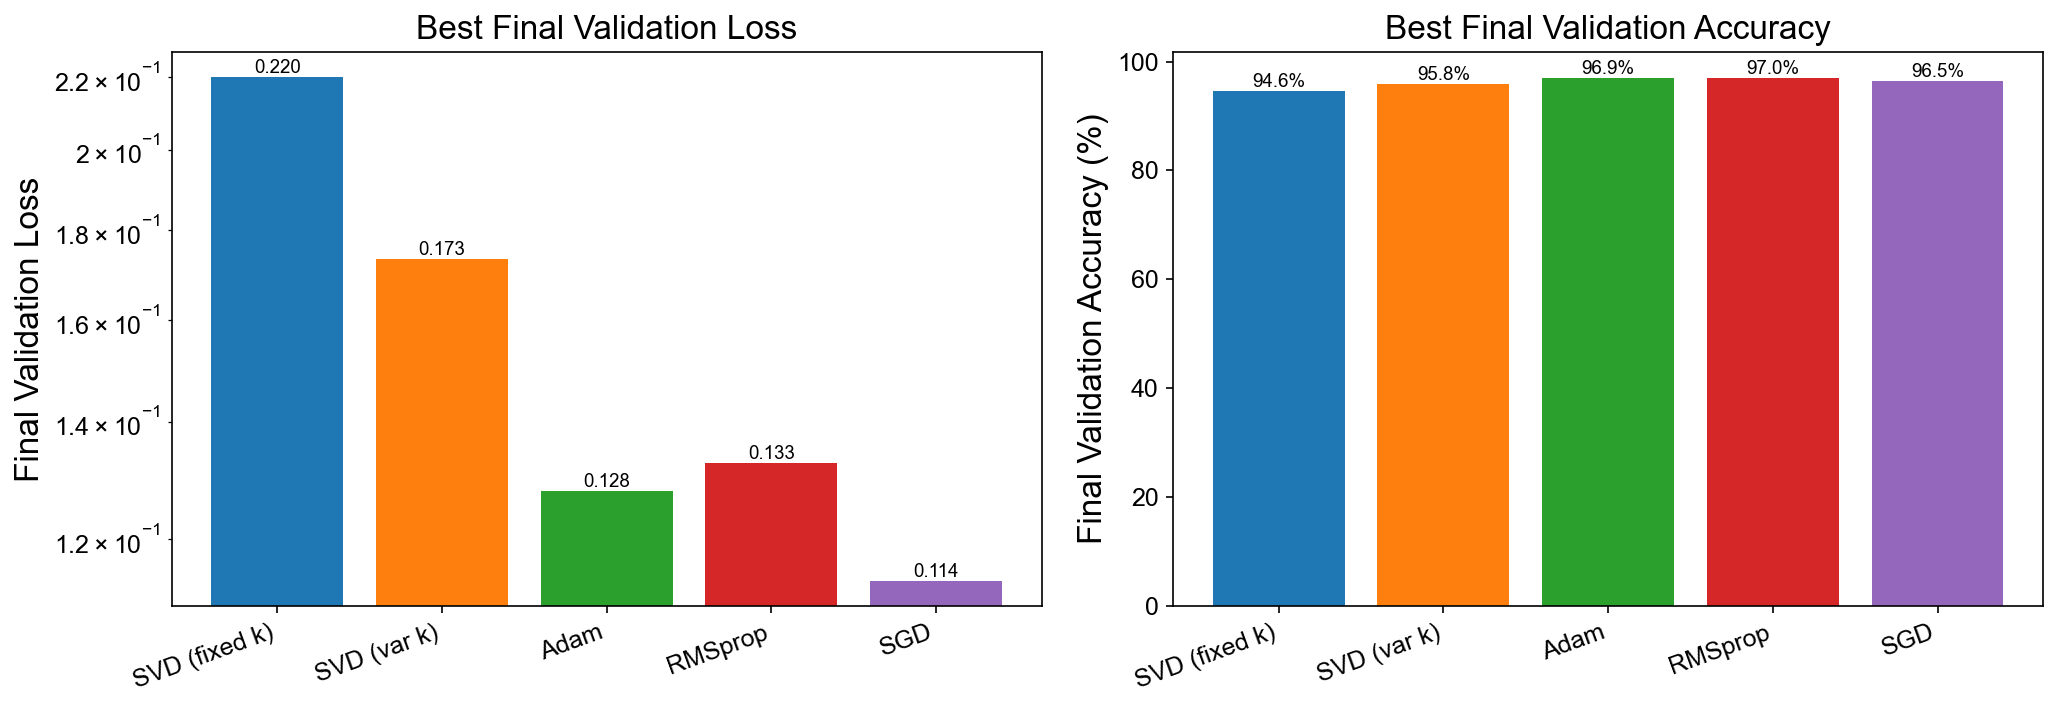

In [5]:
# Bar chart: best final val loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n = len(best_df)
colors = [f'C{i}' for i in range(n)]
x = np.arange(n)

# Loss
ax = axes[0]
bars = ax.bar(x, best_df['final_val_loss'], color=colors)
ax.set_xticks(x)
ax.set_xticklabels(best_df['optimizer'], rotation=20, ha='right')
ax.set_ylabel('Final Validation Loss')
ax.set_title('Best Final Validation Loss')
ax.set_yscale('log')
for bar, val in zip(bars, best_df['final_val_loss']):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9)

# Accuracy
ax = axes[1]
bars = ax.bar(x, best_df['final_val_acc'] * 100, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(best_df['optimizer'], rotation=20, ha='right')
ax.set_ylabel('Final Validation Accuracy (%)')
ax.set_title('Best Final Validation Accuracy')
for bar, val in zip(bars, best_df['final_val_acc']):
    ax.text(bar.get_x() + bar.get_width()/2, val*100, f'{val*100:.1f}%',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'best_optimizer_comparison.pdf')
plt.show()

## 3. Training Curves: Best Configurations

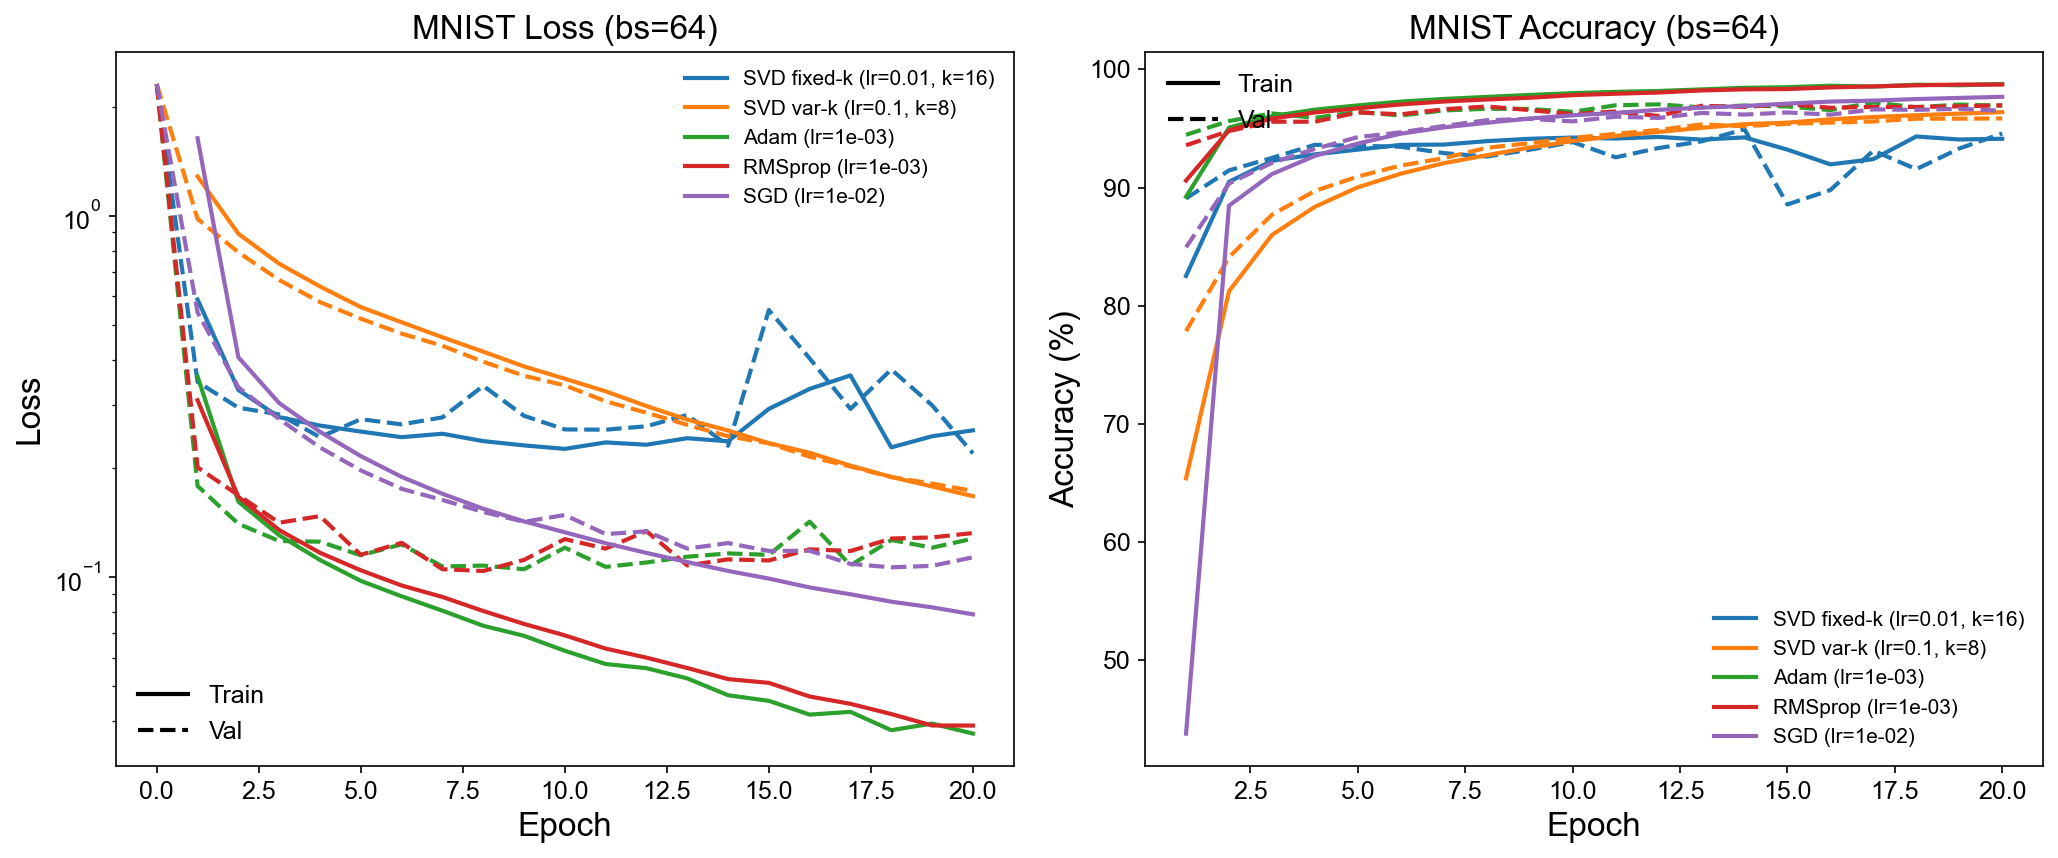

In [6]:
# Loss curves for best configs
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
legend_labels = []

# Collect best rows
best_rows = []
# SVD fixed-k
row = df.loc[df_svd_fixed_k['final_val_loss'].idxmin()]
best_rows.append(('SVD fixed-k', row, f"SVD fixed-k (lr={row['lr']}, k={int(row['k'])})"))
# SVD variable-k
row = df.loc[df_svd_var_k['final_val_loss'].idxmin()]
best_rows.append(('SVD var-k', row, f"SVD var-k (lr={row['lr']}, k={int(row['k'])})"))
# Baselines
for opt in baseline_optimizers:
    opt_df = df_baseline[df_baseline['optimizer'] == opt]
    row = df.loc[opt_df['final_val_loss'].idxmin()]
    best_rows.append((opt, row, f"{opt} (lr={row['lr']:.0e})"))

# Training loss
ax = axes[0]
for i, (name, row, label) in enumerate(best_rows):
    train_curve = get_loss_curve(row, 'train')
    val_curve = get_loss_curve(row, 'val')
    n_ep = len(train_curve)
    ax.plot(range(1, n_ep+1), train_curve, f'C{i}-')
    ax.plot(range(len(val_curve)), val_curve, f'C{i}--')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.set_title('MNIST Loss (bs=64)')

leg1 = ax.legend(handles=[Line2D([], [], color=f'C{i}', linestyle='-', label=best_rows[i][2])
                          for i in range(len(best_rows))], loc='upper right', fontsize=10)
ax.add_artist(leg1)
ax.legend(handles=[Line2D([], [], color='k', linestyle='-', label='Train'),
                   Line2D([], [], color='k', linestyle='--', label='Val')], loc='lower left')

# Accuracy
ax = axes[1]
for i, (name, row, label) in enumerate(best_rows):
    train_acc = get_acc_curve(row, 'train_acc')
    val_acc = get_acc_curve(row, 'val_acc')
    if len(train_acc) > 0:
        ax.plot(range(1, len(train_acc)+1), train_acc*100, f'C{i}-')
    if len(val_acc) > 0:
        ax.plot(range(1, len(val_acc)+1), val_acc*100, f'C{i}--')

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('MNIST Accuracy (bs=64)')

leg1 = ax.legend(handles=[Line2D([], [], color=f'C{i}', linestyle='-', label=best_rows[i][2])
                          for i in range(len(best_rows))], loc='lower right', fontsize=10)
ax.add_artist(leg1)
ax.legend(handles=[Line2D([], [], color='k', linestyle='-', label='Train'),
                   Line2D([], [], color='k', linestyle='--', label='Val')], loc='upper left')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'train_val_curves_best.pdf')
plt.show()

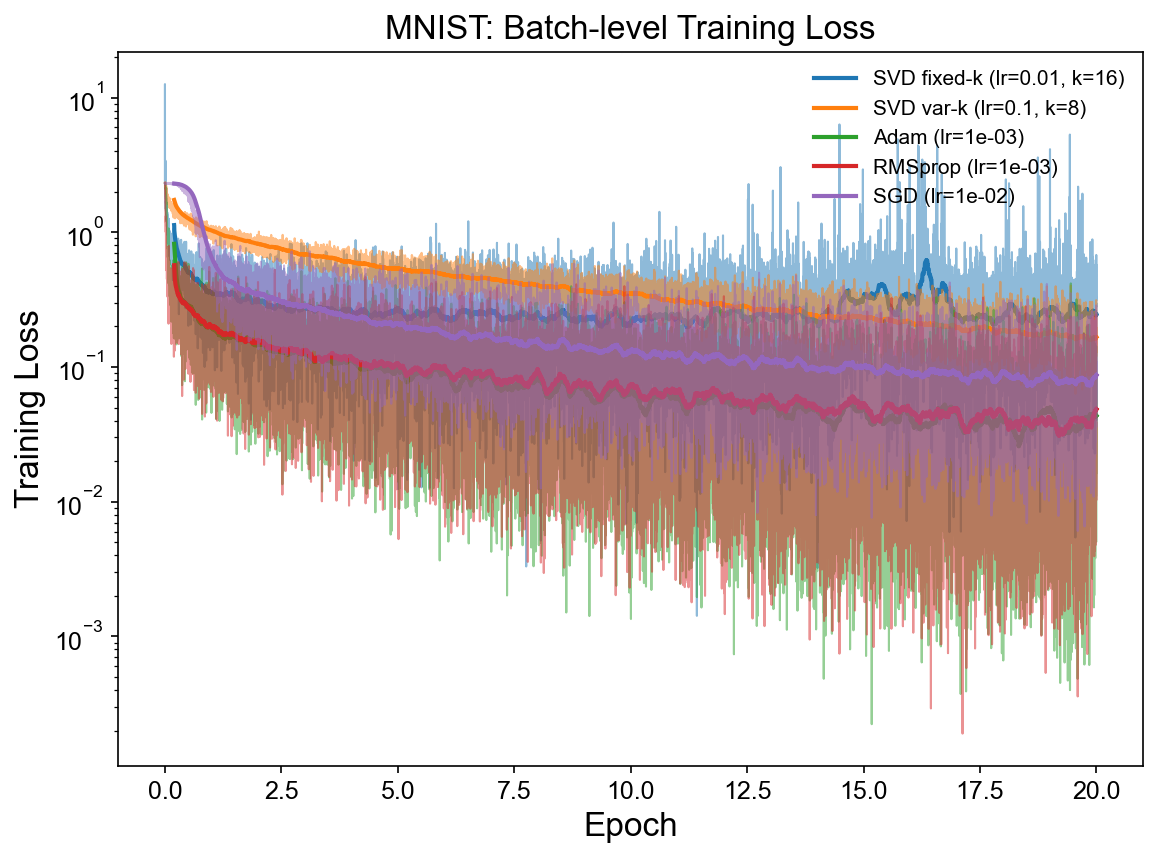

In [7]:
# Batchwise training loss for best configs
fig, ax = plt.subplots(figsize=(8, 6))

for i, (name, row, label) in enumerate(best_rows):
    bl = get_loss_curve(row, 'train_batch')
    n_ep = len(row['losses']['train'])
    ex = np.linspace(0, n_ep, len(bl))
    ax.plot(ex, bl, f'C{i}-', alpha=0.5, lw=1)
    # Smoothed overlay
    sw = max(1, len(bl) // (n_ep * 5))
    if sw > 1:
        bl_smooth = sliding_average(bl, window=sw)
        ax.plot(ex[sw-1:], bl_smooth, f'C{i}-', lw=2, label=label)
    else:
        ax.plot([], [], f'C{i}-', lw=2, label=label)  # for legend

ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_yscale('log')
ax.set_title('MNIST: Batch-level Training Loss')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'training_loss_batchwise_best.pdf')
plt.show()

## 4. Variable k vs Fixed k Analysis

In [8]:
# Compare variable_k vs fixed_k at matched hyperparameters
# Find matching (k_fraction, lr, rtol) pairs
shared_configs = pd.merge(
    df_svd_fixed_k[['k_fraction', 'lr', 'rtol', 'final_val_loss', 'final_val_acc', 'total_time']],
    df_svd_var_k[['k_fraction', 'lr', 'rtol', 'final_val_loss', 'final_val_acc', 'total_time']],
    on=['k_fraction', 'lr', 'rtol'],
    suffixes=('_fixed', '_var')
)

print(f"Matched config pairs: {len(shared_configs)}")
print("\nVariable_k improvement (negative = variable_k is better):")
shared_configs['loss_ratio'] = shared_configs['final_val_loss_var'] / shared_configs['final_val_loss_fixed']
shared_configs['acc_diff'] = shared_configs['final_val_acc_var'] - shared_configs['final_val_acc_fixed']
shared_configs['time_ratio'] = shared_configs['total_time_var'] / shared_configs['total_time_fixed']
print(f"  Loss ratio (var/fixed): median={shared_configs['loss_ratio'].median():.3f}, "
      f"min={shared_configs['loss_ratio'].min():.3f}, max={shared_configs['loss_ratio'].max():.3f}")
print(f"  Acc diff (var-fixed):   median={shared_configs['acc_diff'].median()*100:.2f}%, "
      f"min={shared_configs['acc_diff'].min()*100:.2f}%, max={shared_configs['acc_diff'].max()*100:.2f}%")
print(f"  Time ratio (var/fixed): median={shared_configs['time_ratio'].median():.3f}")

Matched config pairs: 0

Variable_k improvement (negative = variable_k is better):
  Loss ratio (var/fixed): median=nan, min=nan, max=nan
  Acc diff (var-fixed):   median=nan%, min=nan%, max=nan%
  Time ratio (var/fixed): median=nan


In [9]:
# Scatter: fixed_k vs variable_k final val loss
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Loss
ax = axes[0]
ax.scatter(shared_configs['final_val_loss_fixed'], shared_configs['final_val_loss_var'],
           c='C0', alpha=0.7, s=50)
lims = [min(shared_configs['final_val_loss_fixed'].min(), shared_configs['final_val_loss_var'].min()) * 0.8,
        max(shared_configs['final_val_loss_fixed'].max(), shared_configs['final_val_loss_var'].max()) * 1.2]
ax.plot(lims, lims, 'k--', alpha=0.5, label='y=x')
ax.set_xlabel('Final Val Loss (fixed k)')
ax.set_ylabel('Final Val Loss (variable k)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Variable k vs Fixed k: Validation Loss')
ax.legend()

# Accuracy
ax = axes[1]
ax.scatter(shared_configs['final_val_acc_fixed']*100, shared_configs['final_val_acc_var']*100,
           c='C0', alpha=0.7, s=50)
lims = [min(shared_configs['final_val_acc_fixed'].min(), shared_configs['final_val_acc_var'].min()) * 100 - 1,
        max(shared_configs['final_val_acc_fixed'].max(), shared_configs['final_val_acc_var'].max()) * 100 + 1]
ax.plot(lims, lims, 'k--', alpha=0.5, label='y=x')
ax.set_xlabel('Final Val Acc (%) (fixed k)')
ax.set_ylabel('Final Val Acc (%) (variable k)')
ax.set_title('Variable k vs Fixed k: Validation Accuracy')
ax.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / 'variable_k_vs_fixed_k_scatter.pdf')
plt.show()

ValueError: Data has no positive values, and therefore cannot be log-scaled.

Error in callback <function _draw_all_if_interactive at 0x1696e54e0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 2100x900 with 2 Axes>

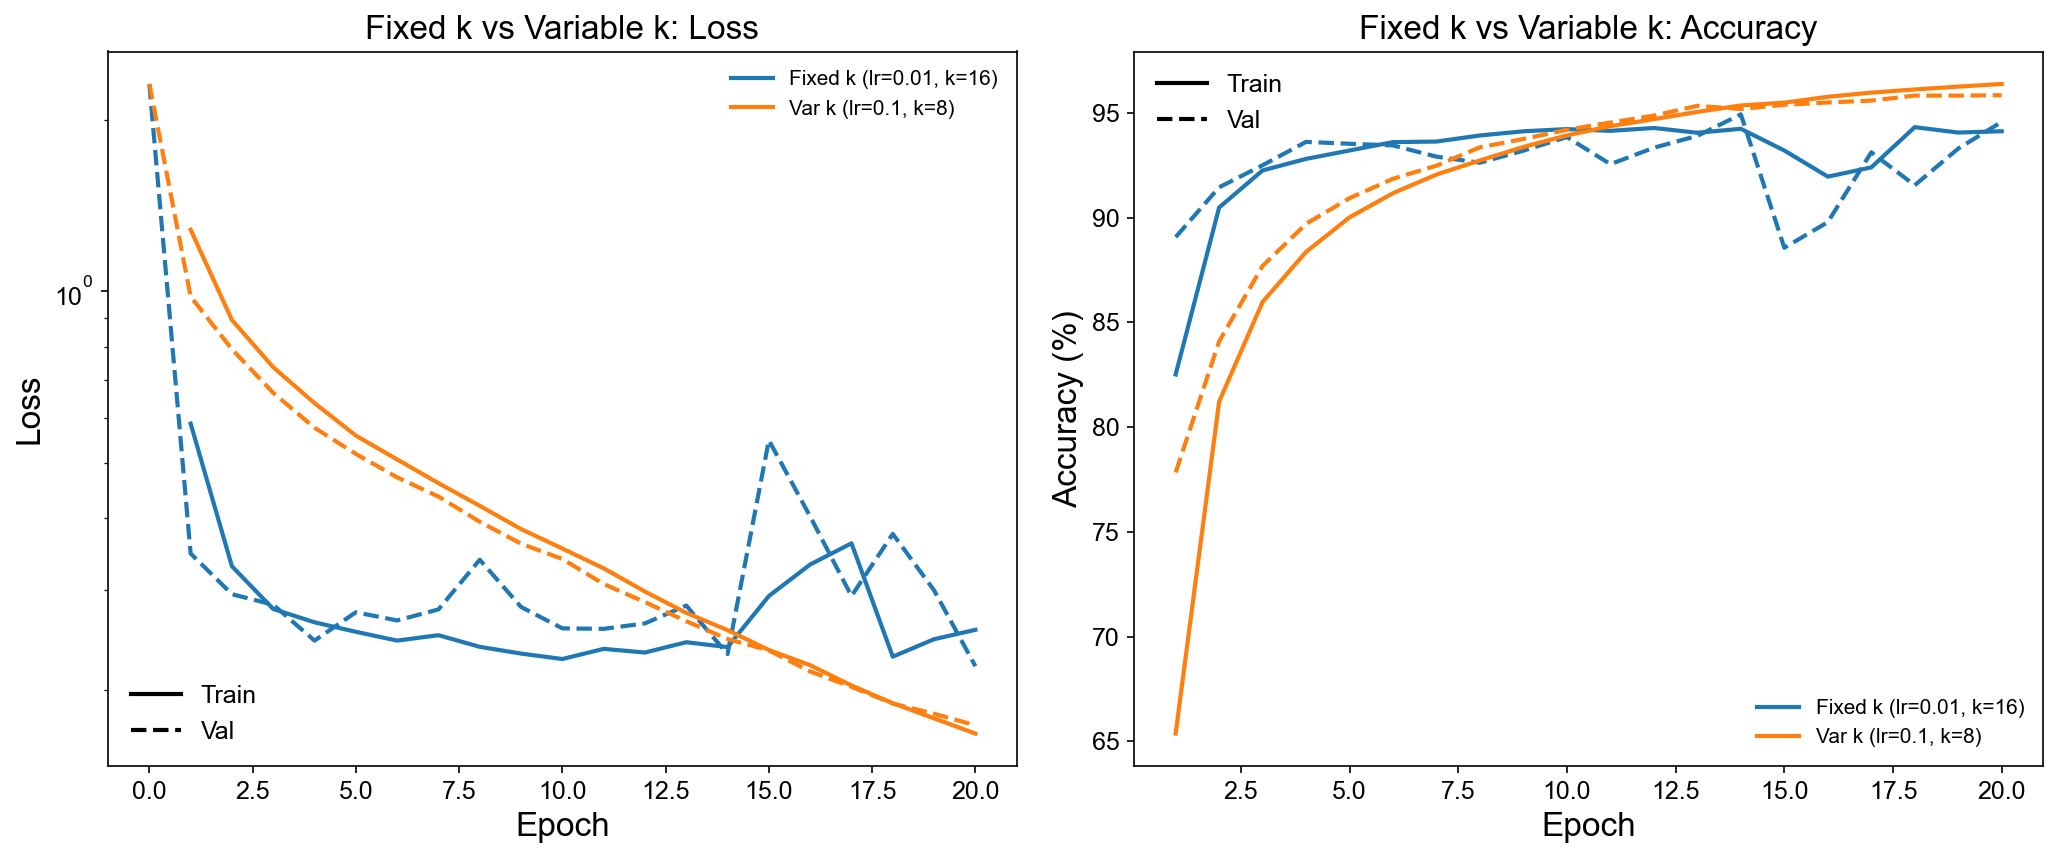

In [10]:
# Training curves: fixed_k vs variable_k at best matched config
# Find the config where they differ the most and the best for each
best_fixed = df_svd_fixed_k.loc[df_svd_fixed_k['final_val_loss'].idxmin()]
best_var = df_svd_var_k.loc[df_svd_var_k['final_val_loss'].idxmin()]

# Also find matched config: same k_fraction, lr, rtol
matched_var = df_svd_var_k[
    (df_svd_var_k['k_fraction'] == best_fixed['k_fraction']) &
    (df_svd_var_k['lr'] == best_fixed['lr']) &
    (df_svd_var_k['rtol'] == best_fixed['rtol'])
]
matched_fixed = df_svd_fixed_k[
    (df_svd_fixed_k['k_fraction'] == best_var['k_fraction']) &
    (df_svd_fixed_k['lr'] == best_var['lr']) &
    (df_svd_fixed_k['rtol'] == best_var['rtol'])
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Loss
ax = axes[0]
n_ep_f = len(best_fixed['losses']['train'])
n_ep_v = len(best_var['losses']['train'])
ax.plot(range(1, n_ep_f+1), get_loss_curve(best_fixed, 'train'), 'C0-',
        label=f"Fixed k (lr={best_fixed['lr']}, k={int(best_fixed['k'])})")
ax.plot(range(len(best_fixed['losses']['val'])), get_loss_curve(best_fixed, 'val'), 'C0--')
ax.plot(range(1, n_ep_v+1), get_loss_curve(best_var, 'train'), 'C1-',
        label=f"Var k (lr={best_var['lr']}, k={int(best_var['k'])})")
ax.plot(range(len(best_var['losses']['val'])), get_loss_curve(best_var, 'val'), 'C1--')

if len(matched_var) > 0:
    mv = matched_var.iloc[0]
    ax.plot(range(1, len(mv['losses']['train'])+1), get_loss_curve(mv, 'train'), 'C2-',
            label=f"Var k matched (lr={mv['lr']}, k={int(mv['k'])})")
    ax.plot(range(len(mv['losses']['val'])), get_loss_curve(mv, 'val'), 'C2--')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_yscale('log')
ax.set_title('Fixed k vs Variable k: Loss')
leg1 = ax.legend(loc='upper right', fontsize=10)
ax.add_artist(leg1)
ax.legend(handles=[Line2D([], [], color='k', linestyle='-', label='Train'),
                   Line2D([], [], color='k', linestyle='--', label='Val')], loc='lower left')

# Accuracy
ax = axes[1]
ta_f = get_acc_curve(best_fixed, 'train_acc')
va_f = get_acc_curve(best_fixed, 'val_acc')
ta_v = get_acc_curve(best_var, 'train_acc')
va_v = get_acc_curve(best_var, 'val_acc')
if len(ta_f) > 0:
    ax.plot(range(1, len(ta_f)+1), ta_f*100, 'C0-',
            label=f"Fixed k (lr={best_fixed['lr']}, k={int(best_fixed['k'])})")
    ax.plot(range(1, len(va_f)+1), va_f*100, 'C0--')
if len(ta_v) > 0:
    ax.plot(range(1, len(ta_v)+1), ta_v*100, 'C1-',
            label=f"Var k (lr={best_var['lr']}, k={int(best_var['k'])})")
    ax.plot(range(1, len(va_v)+1), va_v*100, 'C1--')

if len(matched_var) > 0:
    mv = matched_var.iloc[0]
    ta_m = get_acc_curve(mv, 'train_acc')
    va_m = get_acc_curve(mv, 'val_acc')
    if len(ta_m) > 0:
        ax.plot(range(1, len(ta_m)+1), ta_m*100, 'C2-',
                label=f"Var k matched (lr={mv['lr']}, k={int(mv['k'])})")
        ax.plot(range(1, len(va_m)+1), va_m*100, 'C2--')

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Fixed k vs Variable k: Accuracy')
leg1 = ax.legend(loc='lower right', fontsize=10)
ax.add_artist(leg1)
ax.legend(handles=[Line2D([], [], color='k', linestyle='-', label='Train'),
                   Line2D([], [], color='k', linestyle='--', label='Val')], loc='upper left')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'variable_k_vs_fixed_k_curves.pdf')
plt.show()

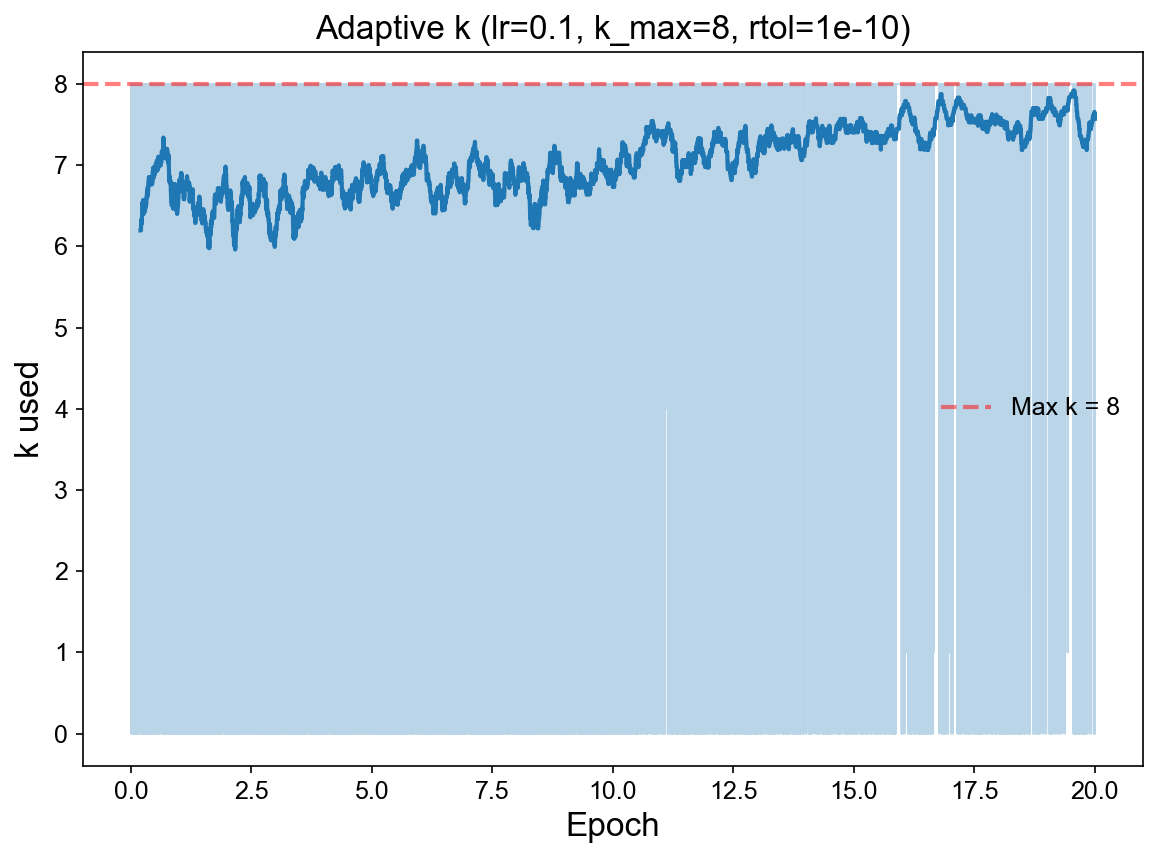

In [11]:
# k_used evolution for variable_k runs
best_var = df_svd_var_k.loc[df_svd_var_k['final_val_loss'].idxmin()]
k_used = best_var['svd_info']['k_used']

if len(k_used) > 0:
    fig, ax = plt.subplots(figsize=(8, 6))
    n_ep = len(best_var['losses']['train'])
    x = np.linspace(0, n_ep, len(k_used))

    ax.plot(x, k_used, 'C0-', alpha=0.3, lw=1)
    sw = max(1, len(k_used) // (n_ep * 5))
    if sw > 1:
        k_smooth = sliding_average(k_used, window=sw)
        ax.plot(x[sw-1:], k_smooth, 'C0-', lw=2)

    ax.axhline(y=best_var['k'], color='r', linestyle='--', alpha=0.5, label=f'Max k = {int(best_var["k"])}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('k used')
    ax.set_title(f"Adaptive k (lr={best_var['lr']}, k_max={int(best_var['k'])}, rtol={best_var['rtol']})")
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'variable_k_evolution_best.pdf')
    plt.show()

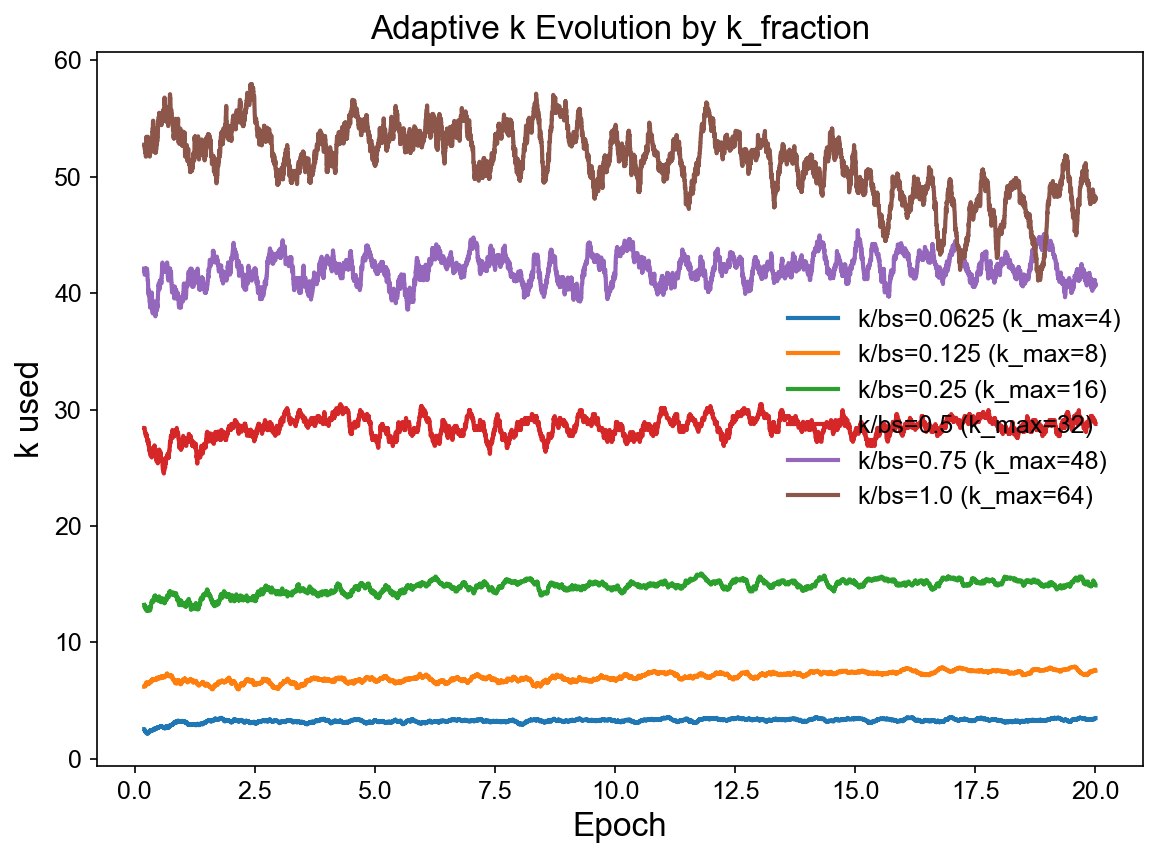

In [12]:
# k_used evolution for multiple variable_k configs
fig, ax = plt.subplots(figsize=(8, 6))
legend_entries = []

# Pick best var-k config at each k_fraction
for i, kf in enumerate(k_fractions):
    kf_data = df_svd_var_k[df_svd_var_k['k_fraction'] == kf]
    if len(kf_data) == 0:
        continue
    best = kf_data.loc[kf_data['final_val_loss'].idxmin()]
    k_used = best['svd_info']['k_used']
    if len(k_used) == 0:
        continue
    n_ep = len(best['losses']['train'])
    x = np.linspace(0, n_ep, len(k_used))
    sw = max(1, len(k_used) // (n_ep * 5))
    if sw > 1:
        k_smooth = sliding_average(k_used, window=sw)
        ax.plot(x[sw-1:], k_smooth, f'C{i}-', lw=2)
    else:
        ax.plot(x, k_used, f'C{i}-', lw=2)
    legend_entries.append(Line2D([], [], color=f'C{i}', label=f'k/bs={kf} (k_max={int(kf*bs)})'))

ax.set_xlabel('Epoch')
ax.set_ylabel('k used')
ax.set_title('Adaptive k Evolution by k_fraction')
if legend_entries:
    ax.legend(handles=legend_entries)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'variable_k_evolution_by_kfraction.pdf')
plt.show()

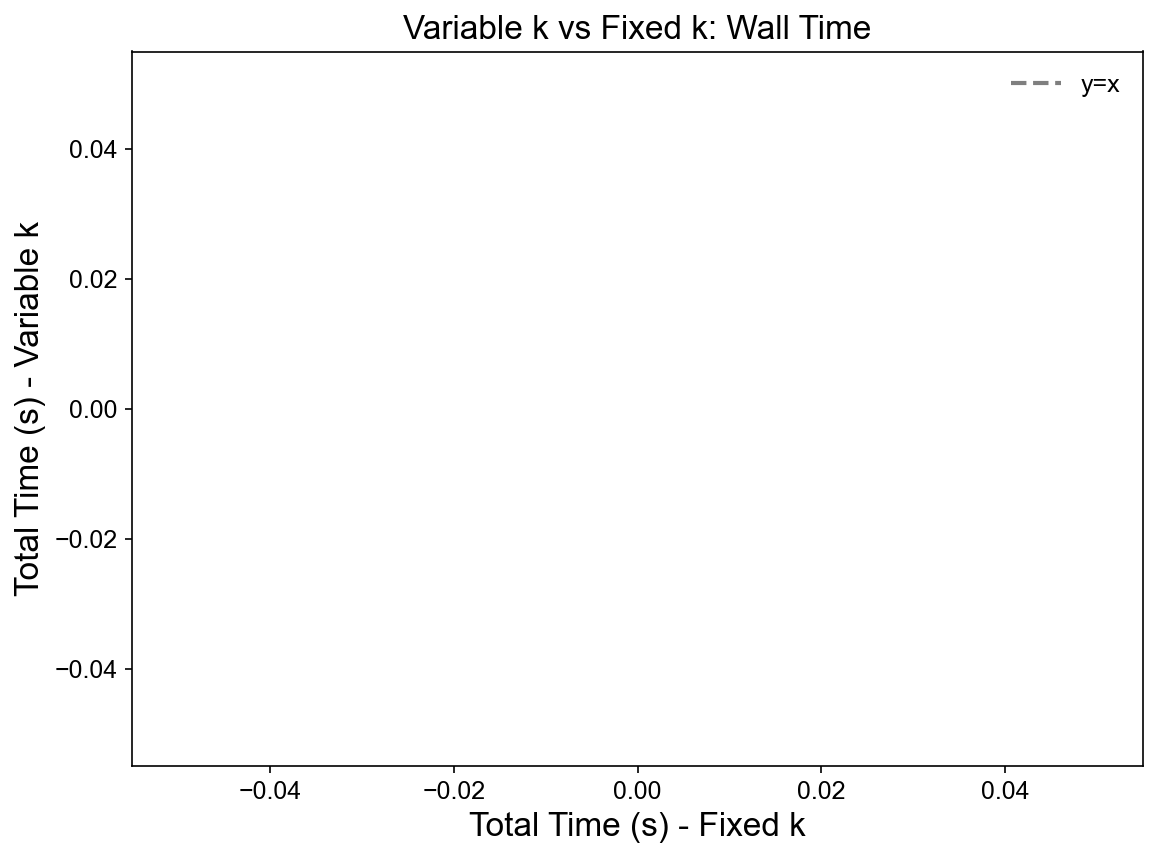

In [13]:
# Wall time: variable_k vs fixed_k
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(shared_configs['total_time_fixed'], shared_configs['total_time_var'],
           c='C0', alpha=0.7, s=50)
lims = [min(shared_configs['total_time_fixed'].min(), shared_configs['total_time_var'].min()) * 0.8,
        max(shared_configs['total_time_fixed'].max(), shared_configs['total_time_var'].max()) * 1.2]
ax.plot(lims, lims, 'k--', alpha=0.5, label='y=x')
ax.set_xlabel('Total Time (s) - Fixed k')
ax.set_ylabel('Total Time (s) - Variable k')
ax.set_title('Variable k vs Fixed k: Wall Time')
ax.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / 'variable_k_vs_fixed_k_walltime.pdf')
plt.show()

## 5. SVD Hyperparameter Sensitivity

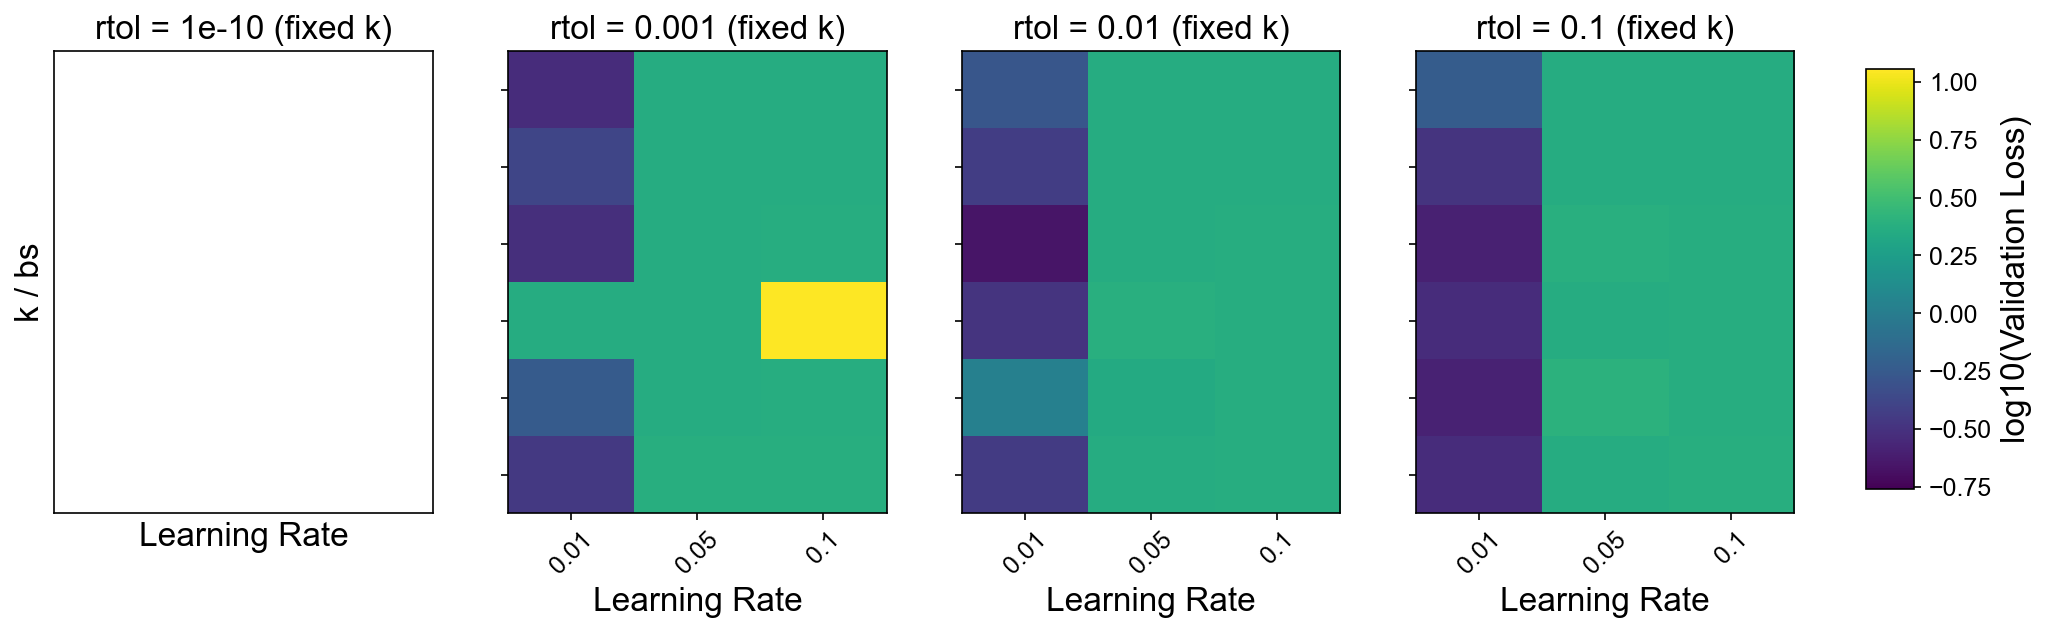

In [14]:
# Heatmaps for fixed_k: val loss vs k_fraction and lr, per rtol
fig, axes = plt.subplots(1, len(svd_rtols), figsize=(4*len(svd_rtols), 4))
if len(svd_rtols) == 1:
    axes = [axes]

for ax, rtol in zip(axes, svd_rtols):
    data = df_svd_fixed_k[df_svd_fixed_k['rtol'] == rtol]
    pivot = data.pivot_table(values='final_val_loss', index='k_fraction', columns='lr', aggfunc='first')
    im = ax.imshow(np.log10(pivot.values), aspect='auto', cmap='viridis',
                   vmin=np.log10(df_svd['final_val_loss'].min()),
                   vmax=np.log10(df_svd['final_val_loss'].max()))
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{lr}' for lr in pivot.columns], rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{kf}' for kf in pivot.index])
    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('k / bs')
    ax.set_title(f'rtol = {rtol} (fixed k)')
    if ax != axes[0]:
        ax.set_ylabel('')
        ax.set_yticklabels([])

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('log10(Validation Loss)')

plt.savefig(PLOT_DIR / 'svd_heatmap_fixed_k.pdf', bbox_inches='tight')
plt.show()

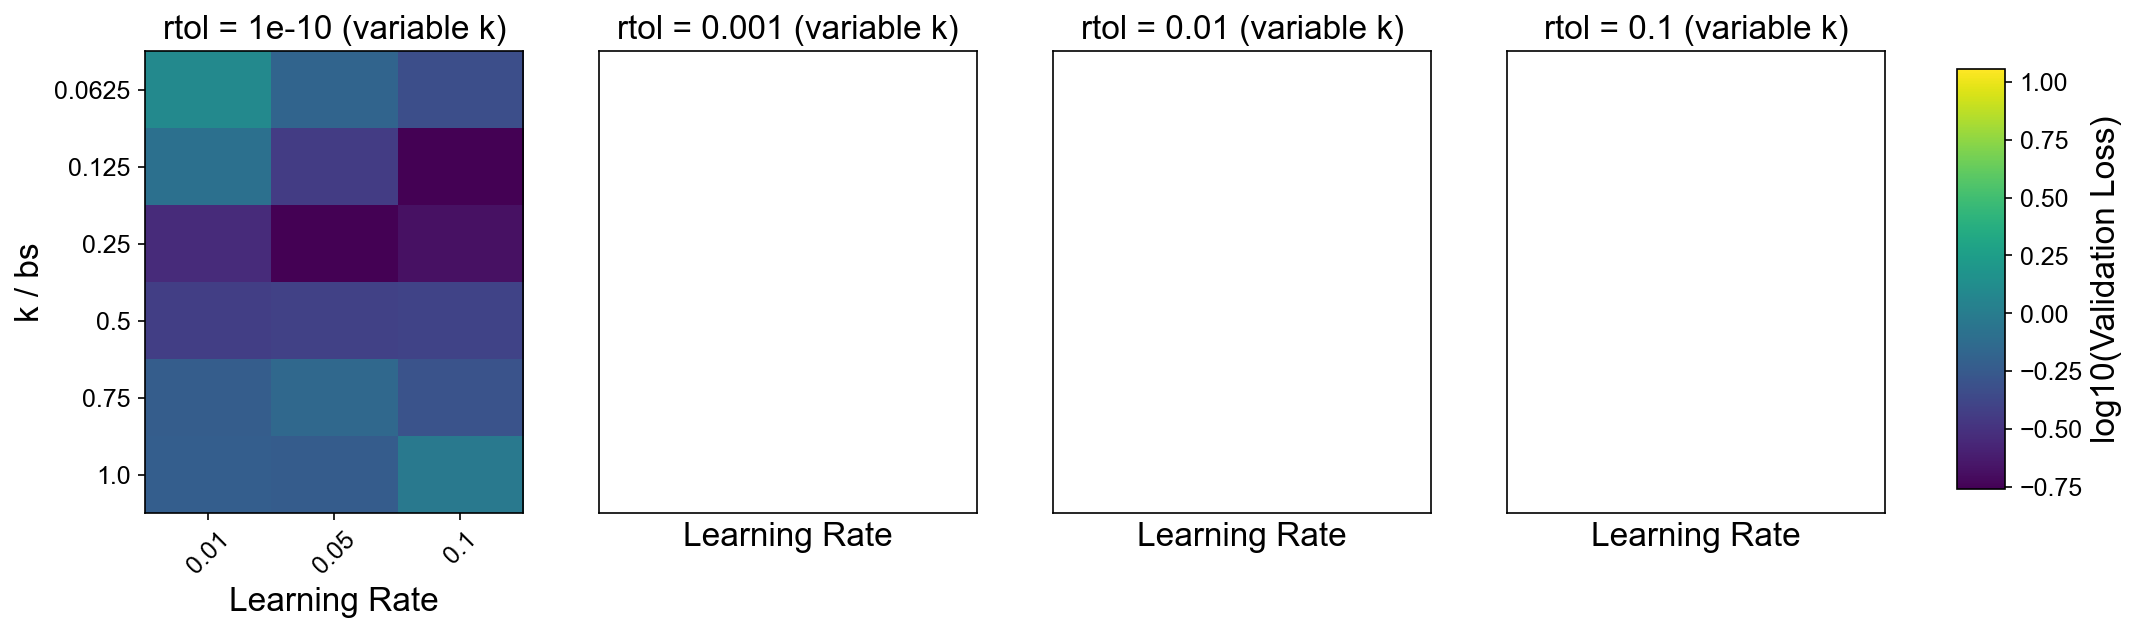

In [15]:
# Same for variable_k
fig, axes = plt.subplots(1, len(svd_rtols), figsize=(4*len(svd_rtols), 4))
if len(svd_rtols) == 1:
    axes = [axes]

for ax, rtol in zip(axes, svd_rtols):
    data = df_svd_var_k[df_svd_var_k['rtol'] == rtol]
    pivot = data.pivot_table(values='final_val_loss', index='k_fraction', columns='lr', aggfunc='first')
    im = ax.imshow(np.log10(pivot.values), aspect='auto', cmap='viridis',
                   vmin=np.log10(df_svd['final_val_loss'].min()),
                   vmax=np.log10(df_svd['final_val_loss'].max()))
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{lr}' for lr in pivot.columns], rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{kf}' for kf in pivot.index])
    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('k / bs')
    ax.set_title(f'rtol = {rtol} (variable k)')
    if ax != axes[0]:
        ax.set_ylabel('')
        ax.set_yticklabels([])

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('log10(Validation Loss)')

plt.savefig(PLOT_DIR / 'svd_heatmap_variable_k.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# LR sensitivity (best across rtol, separately for fixed/variable k)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (subset, title) in zip(axes, [(df_svd_fixed_k, 'Fixed k'), (df_svd_var_k, 'Variable k')]):
    for i, kf in enumerate(k_fractions):
        kf_data = subset[subset['k_fraction'] == kf]
        if len(kf_data) == 0:
            continue
        best_per_lr = kf_data.groupby('lr')['final_val_loss'].min().reset_index()
        ax.plot(best_per_lr['lr'], best_per_lr['final_val_loss'], 'o-',
                label=f'k/bs={kf} (k={int(kf*bs)})', color=f'C{i}')
    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('Final Validation Loss')
    ax.set_title(f'LR Sensitivity - {title}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'lr_sensitivity_fixed_vs_var_k.pdf')
plt.show()

In [ ]:
# k_fraction effect at each lr (fixed k)
for lr in svd_lrs:
    fig, ax = plt.subplots(figsize=(8, 6))
    for i, rtol in enumerate(svd_rtols):
        data = df_svd_fixed_k[(df_svd_fixed_k['lr'] == lr) & (df_svd_fixed_k['rtol'] == rtol)]
        data = data.sort_values('k_fraction')
        ax.plot(data['k_fraction'], data['final_val_loss'], 'o-',
                label=f'rtol={rtol}', color=f'C{i}')
    ax.set_xlabel('k / bs')
    ax.set_ylabel('Final Validation Loss')
    ax.set_title(f'k Fraction Effect (lr={lr}, fixed k)')
    ax.set_yscale('log')
    ax.legend()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'k_fraction_effect_fixedk_lr{lr}.pdf')
    plt.show()

## 6. Singular Value Analysis

In [ ]:
# Nonzero SVs over training for best fixed-k config
smooth = 50

best_svd_row = df.loc[df_svd_fixed_k['final_val_loss'].idxmin()]

fig, ax = plt.subplots(figsize=(8, 6))
ax2 = ax.twinx()

num_nonzero = best_svd_row['svd_info']['num_nonzero_svs']
train_batch = best_svd_row['losses']['train_batch']
n_ep = len(best_svd_row['losses']['train'])
x = np.linspace(0, n_ep, len(num_nonzero))

sw = max(1, len(num_nonzero) // (n_ep * 5))
nn_smooth = sliding_average(num_nonzero, window=sw)
tl_smooth = sliding_average(train_batch, window=sw)

ax.plot(x[sw-1:], nn_smooth, 'C0-', lw=2)
ax2.plot(x[sw-1:], tl_smooth, 'C1--', lw=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('# Nonzero Singular Values', color='C0')
ax2.set_ylabel('Training Loss', color='C1')
ax2.set_yscale('log')
ax.set_title(f"Best SVD (fixed k): lr={best_svd_row['lr']}, k={int(best_svd_row['k'])}")

ax.legend(handles=[Line2D([], [], color='C0', linestyle='-', label='# Nonzero SVs'),
                   Line2D([], [], color='C1', linestyle='--', label='Training Loss')],
          loc='upper right')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'nonzero_svs_vs_trainloss_best_fixedk.pdf')
plt.show()

In [ ]:
# SV spectrum evolution for best fixed-k config
best_svd_row = df.loc[df_svd_fixed_k['final_val_loss'].idxmin()]
svs_list = best_svd_row['svd_info']['svs']
n_ep = len(best_svd_row['losses']['train'])

if svs_list is not None and len(svs_list) > 0:
    total_batches = len(svs_list)
    bpe = total_batches // n_ep
    sample_points = [
        (0, 'Batch 0 (Start)'),
        (bpe, 'Epoch 1'),
        (3*bpe, 'Epoch 3'),
        (n_ep//2*bpe, f'Epoch {n_ep//2}'),
        (3*n_ep//4*bpe, f'Epoch {3*n_ep//4}'),
        (total_batches - 1, f'Epoch {n_ep} (End)'),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, (bidx, title) in zip(axes.flat, sample_points):
        svs = svs_list[min(bidx, len(svs_list)-1)]
        ax.bar(range(len(svs)), sorted(svs, reverse=True), color='C0', alpha=0.7)
        ax.set_xlabel('SV Index')
        ax.set_ylabel('Singular Value')
        ax.set_title(title)
        ax.set_yscale('log')

    plt.suptitle(f"SV Spectrum Evolution (lr={best_svd_row['lr']}, k={int(best_svd_row['k'])})", fontsize=14)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'sv_spectrum_evolution.pdf')
    plt.show()

In [ ]:
# Nonzero SVs comparison across k_fractions for best lr
best_lr = df_svd_fixed_k.loc[df_svd_fixed_k['final_val_loss'].idxmin(), 'lr']
best_rtol = df_svd_fixed_k.loc[df_svd_fixed_k['final_val_loss'].idxmin(), 'rtol']

fig, ax = plt.subplots(figsize=(8, 6))
legend_entries = []

for i, kf in enumerate(k_fractions):
    data = df_svd_fixed_k[(df_svd_fixed_k['lr'] == best_lr) & 
                           (df_svd_fixed_k['rtol'] == best_rtol) &
                           (df_svd_fixed_k['k_fraction'] == kf)]
    if len(data) == 0:
        continue
    row = data.iloc[0]
    if row['svd_info'] is None:
        continue
    num_nonzero = row['svd_info']['num_nonzero_svs']
    n_ep = len(row['losses']['train'])
    x = np.linspace(0, n_ep, len(num_nonzero))
    sw = max(1, len(num_nonzero) // (n_ep * 5))
    if sw > 1:
        nn_smooth = sliding_average(num_nonzero, window=sw)
        ax.plot(x[sw-1:], nn_smooth, f'C{i}-', lw=2)
    else:
        ax.plot(x, num_nonzero, f'C{i}-', lw=2)
    legend_entries.append(Line2D([], [], color=f'C{i}', label=f'k/bs={kf} (k={int(kf*bs)})'))

ax.set_xlabel('Epoch')
ax.set_ylabel('# Nonzero Singular Values')
ax.set_title(f'Nonzero SVs by k_fraction (lr={best_lr}, rtol={best_rtol})')
if legend_entries:
    ax.legend(handles=legend_entries)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'nonzero_svs_by_kfraction.pdf')
plt.show()

## 7. Wall-Time Analysis

In [ ]:
# Total wall time comparison for best configs
fig, ax = plt.subplots(figsize=(8, 5))

n = len(best_df)
colors = [f'C{i}' for i in range(n)]
x = np.arange(n)
bars = ax.bar(x, best_df['total_time'], color=colors)

ax.set_xticks(x)
ax.set_xticklabels(best_df['optimizer'], rotation=20, ha='right')
ax.set_ylabel('Total Time (s)')
ax.set_title('Total Training Time (Best Configs, bs=64)')

for bar, val in zip(bars, best_df['total_time']):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.1f}s',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'total_time_best_configs.pdf')
plt.show()

In [ ]:
# Average batch time comparison
fig, ax = plt.subplots(figsize=(8, 5))

batch_times = []
labels = []

for _, row_data in best_df.iterrows():
    opt_name = row_data['optimizer']
    if 'SVD' in opt_name:
        if 'fixed' in opt_name:
            r = df.loc[df_svd_fixed_k['final_val_loss'].idxmin()]
        else:
            r = df.loc[df_svd_var_k['final_val_loss'].idxmin()]
    else:
        opt_df = df_baseline[df_baseline['optimizer'] == opt_name]
        r = df.loc[opt_df['final_val_loss'].idxmin()]
    batch_times.append(r['avg_batch_time_train'])
    labels.append(opt_name)

x = np.arange(len(labels))
bars = ax.bar(x, [t*1000 for t in batch_times], color=colors)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Avg Batch Time (ms)')
ax.set_title('Average Training Batch Time (Best Configs, bs=64)')

for bar, val in zip(bars, batch_times):
    ax.text(bar.get_x() + bar.get_width()/2, val*1000, f'{val*1000:.1f}ms',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'avg_batch_time_best_configs.pdf')
plt.show()

In [ ]:
# Per-epoch time over training for best configs
fig, ax = plt.subplots(figsize=(8, 6))

for i, (name, row, label) in enumerate(best_rows):
    et = row['losses']['epoch_times']
    ax.plot(range(1, len(et)+1), et, f'C{i}o-', label=label, markersize=4)

ax.set_xlabel('Epoch')
ax.set_ylabel('Epoch Time (s)')
ax.set_title('Per-Epoch Wall Time (Best Configs, bs=64)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'epoch_time_best_configs.pdf')
plt.show()

In [ ]:
# Loss and accuracy vs wall time for best configs
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Loss vs wall time
ax = axes[0]
for i, (name, row, label) in enumerate(best_rows):
    et = row['losses']['epoch_times']
    cum_time = np.cumsum(et)
    val_losses = get_loss_curve(row, 'val')
    cum_time_plot = np.concatenate([[0], cum_time])
    ax.plot(cum_time_plot, val_losses, f'C{i}-', label=label)

ax.set_xlabel('Wall Time (s)')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
ax.set_title('Val Loss vs Wall Time')
ax.legend(fontsize=10)

# Accuracy vs wall time
ax = axes[1]
for i, (name, row, label) in enumerate(best_rows):
    et = row['losses']['epoch_times']
    cum_time = np.cumsum(et)
    val_acc = get_acc_curve(row, 'val_acc')
    if len(val_acc) > 0:
        ax.plot(cum_time[:len(val_acc)], val_acc*100, f'C{i}-', label=label)

ax.set_xlabel('Wall Time (s)')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Val Accuracy vs Wall Time')
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'loss_acc_vs_walltime_best.pdf')
plt.show()

In [ ]:
# SVD wall time vs k_fraction
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (subset, title) in zip(axes, [(df_svd_fixed_k, 'Fixed k'), (df_svd_var_k, 'Variable k')]):
    for i, lr in enumerate(svd_lrs):
        data = subset[subset['lr'] == lr]
        avg_per_kf = data.groupby('k_fraction')['total_time'].mean().reset_index()
        ax.plot(avg_per_kf['k_fraction'], avg_per_kf['total_time'], 'o-',
                label=f'lr={lr}', color=f'C{i}')
    ax.set_xlabel('k / bs')
    ax.set_ylabel('Total Training Time (s)')
    ax.set_title(f'SVD Wall Time vs k Fraction ({title})')
    ax.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / 'svd_walltime_vs_kfraction.pdf')
plt.show()

In [ ]:
# Efficiency scatter: val loss vs total time (all runs)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Loss
ax = axes[0]
ax.scatter(df_svd_fixed_k['total_time'], df_svd_fixed_k['final_val_loss'],
           c='C0', alpha=0.5, label='SVD fixed-k', s=40)
ax.scatter(df_svd_var_k['total_time'], df_svd_var_k['final_val_loss'],
           c='C1', alpha=0.5, label='SVD var-k', s=40, marker='^')
for i, opt in enumerate(baseline_optimizers):
    od = df_baseline[df_baseline['optimizer'] == opt]
    ax.scatter(od['total_time'], od['final_val_loss'],
               c=f'C{i+2}', alpha=0.6, label=opt, s=40, marker='s')

ax.set_xlabel('Total Training Time (s)')
ax.set_ylabel('Final Validation Loss')
ax.set_yscale('log')
ax.set_title('Loss vs Wall Time')
ax.legend(fontsize=10)

# Accuracy
ax = axes[1]
ax.scatter(df_svd_fixed_k['total_time'], df_svd_fixed_k['final_val_acc']*100,
           c='C0', alpha=0.5, label='SVD fixed-k', s=40)
ax.scatter(df_svd_var_k['total_time'], df_svd_var_k['final_val_acc']*100,
           c='C1', alpha=0.5, label='SVD var-k', s=40, marker='^')
for i, opt in enumerate(baseline_optimizers):
    od = df_baseline[df_baseline['optimizer'] == opt]
    ax.scatter(od['total_time'], od['final_val_acc']*100,
               c=f'C{i+2}', alpha=0.6, label=opt, s=40, marker='s')

ax.set_xlabel('Total Training Time (s)')
ax.set_ylabel('Final Validation Accuracy (%)')
ax.set_title('Accuracy vs Wall Time')
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'efficiency_scatter.pdf')
plt.show()

### 7.1 Wall-Time Analysis (Excluding Compilation Overhead)

The SVD optimizer uses `torch.compile`, so the first batch/epoch includes significant JIT compilation time. These plots exclude the first epoch to show steady-state performance.

In [ ]:
# Compute timing excluding first epoch
def get_time_excl_first_epoch(row):
    et = row['losses'].get('epoch_times', [])
    if len(et) > 1:
        return sum(et[1:])
    return np.nan

def get_avg_batch_time_excl_first(row):
    bt = row['losses'].get('batch_times_train', [])
    if len(bt) > 1:
        return np.mean(bt[1:])
    return np.nan

df['time_excl_first_epoch'] = df.apply(get_time_excl_first_epoch, axis=1)
df['avg_batch_time_excl_first'] = df.apply(get_avg_batch_time_excl_first, axis=1)
df_svd = df[df['optimizer'] == 'SVD'].copy()
df_baseline = df[df['optimizer'] != 'SVD'].copy()
df_svd_fixed_k = df_svd[df_svd['variable_k'] == False].copy()
df_svd_var_k = df_svd[df_svd['variable_k'] == True].copy()

# Show compilation overhead for best SVD fixed-k config
best_svd_row = df.loc[df_svd_fixed_k['final_val_loss'].idxmin()]
et = best_svd_row['losses']['epoch_times']
bt = best_svd_row['losses']['batch_times_train']
print(f"Best SVD (fixed k) compilation overhead:")
print(f"  Epoch 1 time: {et[0]:.2f}s vs Epoch 2+ avg: {np.mean(et[1:]):.2f}s ({et[0]/np.mean(et[1:]):.1f}x)")
print(f"  Batch 1 time: {bt[0]*1000:.1f}ms vs Batch 2+ avg: {np.mean(bt[1:])*1000:.2f}ms ({bt[0]/np.mean(bt[1:]):.0f}x)")

In [ ]:
# Total time excluding first epoch
fig, ax = plt.subplots(figsize=(8, 5))

best_times_excl = []
best_labels = []

# SVD fixed-k
r = df.loc[df_svd_fixed_k['final_val_loss'].idxmin()]
best_times_excl.append(r['time_excl_first_epoch'])
best_labels.append('SVD (fixed k)')
# SVD var-k
r = df.loc[df_svd_var_k['final_val_loss'].idxmin()]
best_times_excl.append(r['time_excl_first_epoch'])
best_labels.append('SVD (var k)')

for opt in baseline_optimizers:
    opt_df = df_baseline[df_baseline['optimizer'] == opt]
    best_row = df.loc[opt_df['final_val_loss'].idxmin()]
    best_times_excl.append(best_row['time_excl_first_epoch'])
    best_labels.append(opt)

n = len(best_labels)
colors = [f'C{i}' for i in range(n)]
x = np.arange(n)
bars = ax.bar(x, best_times_excl, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(best_labels, rotation=20, ha='right')
ax.set_ylabel('Total Time (s)')
ax.set_title('Total Training Time Excl. First Epoch (Best Configs, bs=64)')

for bar, val in zip(bars, best_times_excl):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.1f}s',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'total_time_excl_first_epoch.pdf')
plt.show()

In [ ]:
# Average batch time excluding first batch
fig, ax = plt.subplots(figsize=(8, 5))

batch_times_excl = []
labels = []

for _, row_data in best_df.iterrows():
    opt_name = row_data['optimizer']
    if 'SVD' in opt_name:
        if 'fixed' in opt_name:
            r = df.loc[df_svd_fixed_k['final_val_loss'].idxmin()]
        else:
            r = df.loc[df_svd_var_k['final_val_loss'].idxmin()]
    else:
        opt_df = df_baseline[df_baseline['optimizer'] == opt_name]
        r = df.loc[opt_df['final_val_loss'].idxmin()]
    batch_times_excl.append(r['avg_batch_time_excl_first'])
    labels.append(opt_name)

n = len(labels)
colors = [f'C{i}' for i in range(n)]
x = np.arange(n)
bars = ax.bar(x, [t*1000 for t in batch_times_excl], color=colors)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Avg Batch Time (ms)')
ax.set_title('Avg Batch Time Excl. First Batch (Best Configs, bs=64)')

for bar, val in zip(bars, batch_times_excl):
    ax.text(bar.get_x() + bar.get_width()/2, val*1000, f'{val*1000:.1f}ms',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'avg_batch_time_excl_first_batch.pdf')
plt.show()

In [ ]:
# Loss and accuracy vs wall time excluding first epoch
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Loss vs wall time
ax = axes[0]
for i, (name, row, label) in enumerate(best_rows):
    et = row['losses']['epoch_times']
    cum_time_from_e2 = np.cumsum(et[1:])
    val_losses = get_loss_curve(row, 'val')
    ax.plot(np.concatenate([[0], cum_time_from_e2]), val_losses[1:], f'C{i}-', label=label)

ax.set_xlabel('Wall Time (s), excl. first epoch')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
ax.set_title('Val Loss vs Wall Time (excl. 1st epoch)')
ax.legend(fontsize=10)

# Accuracy vs wall time
ax = axes[1]
for i, (name, row, label) in enumerate(best_rows):
    et = row['losses']['epoch_times']
    cum_time_from_e2 = np.cumsum(et[1:])
    val_acc = get_acc_curve(row, 'val_acc')
    if len(val_acc) > 1:
        ax.plot(cum_time_from_e2[:len(val_acc)-1], val_acc[1:]*100, f'C{i}-', label=label)

ax.set_xlabel('Wall Time (s), excl. first epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Val Accuracy vs Wall Time (excl. 1st epoch)')
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'loss_acc_vs_walltime_excl_first_epoch.pdf')
plt.show()

In [ ]:
# Efficiency scatter excluding first epoch
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Loss
ax = axes[0]
ax.scatter(df_svd_fixed_k['time_excl_first_epoch'], df_svd_fixed_k['final_val_loss'],
           c='C0', alpha=0.5, label='SVD fixed-k', s=40)
ax.scatter(df_svd_var_k['time_excl_first_epoch'], df_svd_var_k['final_val_loss'],
           c='C1', alpha=0.5, label='SVD var-k', s=40, marker='^')
for i, opt in enumerate(baseline_optimizers):
    od = df_baseline[df_baseline['optimizer'] == opt]
    ax.scatter(od['time_excl_first_epoch'], od['final_val_loss'],
               c=f'C{i+2}', alpha=0.6, label=opt, s=40, marker='s')

ax.set_xlabel('Total Time excl. 1st epoch (s)')
ax.set_ylabel('Final Validation Loss')
ax.set_yscale('log')
ax.set_title('Loss vs Wall Time (excl. 1st epoch)')
ax.legend(fontsize=10)

# Accuracy
ax = axes[1]
ax.scatter(df_svd_fixed_k['time_excl_first_epoch'], df_svd_fixed_k['final_val_acc']*100,
           c='C0', alpha=0.5, label='SVD fixed-k', s=40)
ax.scatter(df_svd_var_k['time_excl_first_epoch'], df_svd_var_k['final_val_acc']*100,
           c='C1', alpha=0.5, label='SVD var-k', s=40, marker='^')
for i, opt in enumerate(baseline_optimizers):
    od = df_baseline[df_baseline['optimizer'] == opt]
    ax.scatter(od['time_excl_first_epoch'], od['final_val_acc']*100,
               c=f'C{i+2}', alpha=0.6, label=opt, s=40, marker='s')

ax.set_xlabel('Total Time excl. 1st epoch (s)')
ax.set_ylabel('Final Validation Accuracy (%)')
ax.set_title('Accuracy vs Wall Time (excl. 1st epoch)')
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'efficiency_scatter_excl_first_epoch.pdf')
plt.show()

## 8. Summary

In [ ]:
print("=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)

print("\nBest performance by optimizer:")
print(best_df.to_string(index=False))

print("\n" + "-" * 70)
print(f"\nSVD fixed-k ({len(df_svd_fixed_k)} runs):")
print(f"  Val loss:  min={df_svd_fixed_k['final_val_loss'].min():.4f}, "
      f"median={df_svd_fixed_k['final_val_loss'].median():.4f}")
print(f"  Val acc:   max={df_svd_fixed_k['final_val_acc'].max()*100:.1f}%, "
      f"median={df_svd_fixed_k['final_val_acc'].median()*100:.1f}%")
print(f"  Time:      min={df_svd_fixed_k['total_time'].min():.1f}s, "
      f"median={df_svd_fixed_k['total_time'].median():.1f}s")

print(f"\nSVD variable-k ({len(df_svd_var_k)} runs):")
print(f"  Val loss:  min={df_svd_var_k['final_val_loss'].min():.4f}, "
      f"median={df_svd_var_k['final_val_loss'].median():.4f}")
print(f"  Val acc:   max={df_svd_var_k['final_val_acc'].max()*100:.1f}%, "
      f"median={df_svd_var_k['final_val_acc'].median()*100:.1f}%")
print(f"  Time:      min={df_svd_var_k['total_time'].min():.1f}s, "
      f"median={df_svd_var_k['total_time'].median():.1f}s")

print(f"\nBaseline optimizers:")
for opt in baseline_optimizers:
    od = df_baseline[df_baseline['optimizer'] == opt]
    print(f"  {opt} ({len(od)} runs): "
          f"val_loss min={od['final_val_loss'].min():.4f}, "
          f"val_acc max={od['final_val_acc'].max()*100:.1f}%, "
          f"time min={od['total_time'].min():.1f}s")

print(f"\nVariable k vs Fixed k (matched configs):")
print(f"  Median loss ratio (var/fixed): {shared_configs['loss_ratio'].median():.3f}")
print(f"  Median acc diff (var-fixed):   {shared_configs['acc_diff'].median()*100:.2f}%")
print(f"  Median time ratio (var/fixed): {shared_configs['time_ratio'].median():.3f}")

print(f"\nAll plots saved to: {PLOT_DIR.resolve()}")